In [45]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
from functools import partial


In [46]:
# 目的関数（最適化したい関数）を定義
def objective(trial):
    # 探索空間をlistで指定
    search_range = [0, 1, 2, 3]
    x = trial.suggest_categorical('x', search_range)
    # int, float
    y = trial.suggest_int('y', 1, 10)
    z = trial.suggest_float('z', -10, 10)
    # uniform: 範囲内の線形の連続値を探索
    w = trial.suggest_uniform('w', 0.0, 2.0)
    # Discrete-uniform parameter
    w2 = trial.suggest_discrete_uniform('w2', 0.0, 1.0, 0.1)
    return (x + y + z + w + w2 - 2) ** 2  # 最小化したい関数


In [47]:
# スタディ（最適化プロセス）を作成して最適化を実行
study = optuna.create_study(direction='minimize')  # 最小化問題なので 'minimize' を指定
study.optimize(objective, n_trials=10)  # 100回試行して最適解を探索


[I 2025-05-10 19:07:57,644] A new study created in memory with name: no-name-c1f1d50a-6889-4d6f-8eaf-007f33a2ab0c
C:\Users\zeroc\AppData\Local\Temp\ipykernel_20076\11153018.py:10: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  w = trial.suggest_uniform('w', 0.0, 2.0)
C:\Users\zeroc\AppData\Local\Temp\ipykernel_20076\11153018.py:12: FutureWarning: suggest_discrete_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., step=...) instead.
  w2 = trial.suggest_discrete_uniform('w2', 0.0, 1.0, 0.1)
[I 2025-05-10 19:07:57,647] Trial 0 finished with value: 175.21261968483864 and parameters: {'x': 3, 'y': 8, 'z': 3.3113187121406735, 'w': 0.22547167242153932, 'w2': 0.7000000000000001}. Best is trial 0 with value: 175.21261968483864.
[I 2025-05-10 19:07

In [48]:
# 最適解を表示
print(f"最適な params: {study.best_params}")
print(f"最小値: {study.best_value}")

最適な params: {'x': 1, 'y': 4, 'z': -2.527201687868981, 'w': 0.6125951241198642, 'w2': 0.0}
最小値: 1.1780789114565002


---

### tips: objectiveに引数を足したいとき
- partial関数を利用することで引数を追加できる

In [49]:

# 目的関数を定義
def objective_org(trial, ex_val, msg):
    x = trial.suggest_float('x', -10, 10)
    y = trial.suggest_float('y', -10, 10)

    # 制約条件を満たさない場合は None を返して無効化
    # if x + y > 5:
    #     return None  
    # 最適化する関数
    value = (x - 2) ** 2 + (y + 3) ** 2 + np.sin(3 * x) + np.cos(2 * y) + ex_val
    print(f'[DBG] {msg=}')
    return value  # 最小化する


In [50]:
objective = partial(objective_org, ex_val=1, msg='test message!')  # 目的関数をラップして引数を追加

In [51]:
from optuna.samplers import CmaEsSampler, RandomSampler, TPESampler

In [52]:

# スタディ（最適化の実行）
# デフォルトのサンプラーはTPESampler
study = optuna.create_study(direction='minimize')
# samplerを指定することも可能
# study = optuna.create_study(direction="minimize", sampler=RandomSampler())
# study = optuna.create_study(direction="minimize", sampler=CmaEsSampler())
study.optimize(objective, n_trials=10)  # 200回試行


[I 2025-05-10 19:07:57,735] A new study created in memory with name: no-name-100675a3-13dd-4a4d-9102-f8e00dd14613
[I 2025-05-10 19:07:57,736] Trial 0 finished with value: 99.51461635737904 and parameters: {'x': 9.131632124066414, 'y': -9.792865115159092}. Best is trial 0 with value: 99.51461635737904.
[I 2025-05-10 19:07:57,737] Trial 1 finished with value: 79.61437943747617 and parameters: {'x': -4.601559657086289, 'y': 2.9223025301343757}. Best is trial 1 with value: 79.61437943747617.
[I 2025-05-10 19:07:57,737] Trial 2 finished with value: 11.743155656573114 and parameters: {'x': 5.086733877224571, 'y': -1.6727629027582687}. Best is trial 2 with value: 11.743155656573114.
[I 2025-05-10 19:07:57,738] Trial 3 finished with value: 22.13641614017087 and parameters: {'x': 1.8450249547574842, 'y': 1.7662576259269471}. Best is trial 2 with value: 11.743155656573114.
[I 2025-05-10 19:07:57,738] Trial 4 finished with value: 81.9889414659701 and parameters: {'x': -4.733383204649481, 'y': -8.

[DBG] msg='test message!'
[DBG] msg='test message!'
[DBG] msg='test message!'
[DBG] msg='test message!'
[DBG] msg='test message!'
[DBG] msg='test message!'
[DBG] msg='test message!'
[DBG] msg='test message!'
[DBG] msg='test message!'
[DBG] msg='test message!'


In [53]:

# 結果を表示
print(f"最適な x: {study.best_params['x']}")
print(f"最適な y: {study.best_params['y']}")
print(f"最小値: {study.best_value}")


最適な x: 5.086733877224571
最適な y: -1.6727629027582687
最小値: 11.743155656573114


C:\Users\zeroc\AppData\Local\Temp\ipykernel_20076\930593018.py:4: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Figure size 1000x400 with 0 Axes>

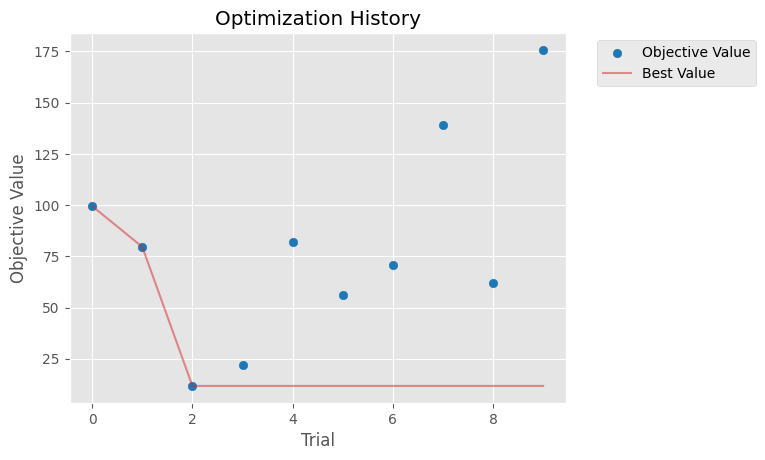

In [54]:

# **結果の可視化**
# 試行ごとの目的関数の推移
plt.figure(figsize=(10, 4))
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optimization History")
plt.show()


In [55]:

# パラメータの分布
# plt.figure(figsize=(10, 4))
# optuna.visualization.matplotlib.plot_param_importances(study)
# plt.title("Parameter Importance")
# plt.show()
